In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import shap

In [14]:
#Time-Based Split
df = pd.read_csv('modelling_dataset_top5.csv', parse_dates=["date"])
split_date = "2017-01-01"
train_df = df[df["date"] < split_date]
test_df = df[df["date"] >= split_date]
print(train_df.shape, test_df.shape)

(385290, 41) (61290, 41)


In [15]:
#Feature Selection
drop_cols = ["id", "date", "sales", "log_sales"]
x_train = train_df.drop(columns=drop_cols)
y_train = train_df["log_sales"]
x_test = test_df.drop(columns=drop_cols)
y_test = test_df["log_sales"]

In [16]:
#Identify Categorical VS Numerical Columns
cat_cols = x_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = x_train.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", len(num_cols))

Categorical: ['family', 'city', 'state', 'store_type']
Numeric: 33


In [17]:
#Build Pre-processors
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [18]:
#Naive Forecast - Baseline Model
naive_pred = test_df["lag_1"]
mae_naive = mean_absolute_error(test_df["sales"], naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test_df["sales"], naive_pred))
print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 700.0859390316202
Naive RMSE: 1333.081223571666


In [19]:
#Linear Regression
lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
lr_model.fit(x_train, y_train)
lr_pred_log = lr_model.predict(x_test)
print("Log prediction range:", lr_pred_log.min(), lr_pred_log.max())

Log prediction range: -0.6522314721605653 16.965609071660708


In [20]:
lr_pred = np.expm1(lr_pred_log)
print("Raw prediction range:", lr_pred.min(), lr_pred.max())

Raw prediction range: -0.47911785506749605 23338362.616166178


In [21]:
mae_lr = mean_absolute_error(test_df["sales"], lr_pred)
rmse_lr = np.sqrt(mean_squared_error(test_df["sales"], lr_pred))
print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 28371.20746234712
Linear Regression RMSE: 250607.79967613384


In [22]:
#Random Forest
rf_model= Pipeline(steps=[
    ("preprocess", preprocess),
    ("model",RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=1))
])
rf_model.fit(x_train, y_train)
rf_pred_log = rf_model.predict(x_test)
rf_pred = np.expm1(rf_pred_log)
mae_rf = mean_absolute_error(test_df["sales"], rf_pred)
rmse_rf = np.sqrt(mean_squared_error(test_df["sales"], rf_pred))
print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 368.1254626024003
Random Forest RMSE: 762.5527343703599


In [23]:
#XGBoost
xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(x_train, y_train)
xgb_pred_log = xgb_model.predict(x_test)
xgb_pred = np.expm1(xgb_pred_log)
mae_xgb = mean_absolute_error(test_df["sales"], xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(test_df["sales"], xgb_pred))
print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 326.15018544218754
XGBoost RMSE: 707.6053149161636


<font size="5">Results</font>

In [24]:
results = pd.DataFrame({
    "Model": ["Naive", "Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_naive, mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_naive, rmse_lr, rmse_rf, rmse_xgb]
})
results_sorted = results.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
baseline_rmse = rmse_naive
results_sorted["RMSE Improvement vs Naive (%)"] = (
    (baseline_rmse - results_sorted["RMSE"]) / baseline_rmse * 100
)
results_styled = results_sorted.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "RMSE Improvement vs Naive (%)": "{:.1f}%"
})
results_styled

,Model,MAE,RMSE,RMSE Improvement vs Naive (%)
0,XGBoost,326.15,707.61,46.9%
1,Random Forest,368.13,762.55,42.8%
2,Naive,700.09,"1,333.08",0.0%
3,Linear Regression,"28,371.21","250,607.80",-18699.1%


<font size="5">Feature Importance (XGBoost)</font>

In [25]:
xgb = xgb_model.named_steps["model"]
preprocessor = xgb_model.named_steps["preprocess"]
num_features = num_cols
cat_features = preprocessor.named_transformers_["cat"] \
                           .named_steps["onehot"] \
                           .get_feature_names_out(cat_cols)

all_features = list(num_features) + list(cat_features)
importances = xgb.feature_importances_
fi = pd.DataFrame({"feature": all_features, "importance": importances})
fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)
fi_head = fi.head(30).copy()
fi.head().style.format({"importance":"{:.6f}"})

,feature,importance
0,lag_1,0.466340
1,rolling_mean_7,0.356799
2,rolling_std_7,0.056332
3,lag_7,0.029258
4,lag_14,0.015723


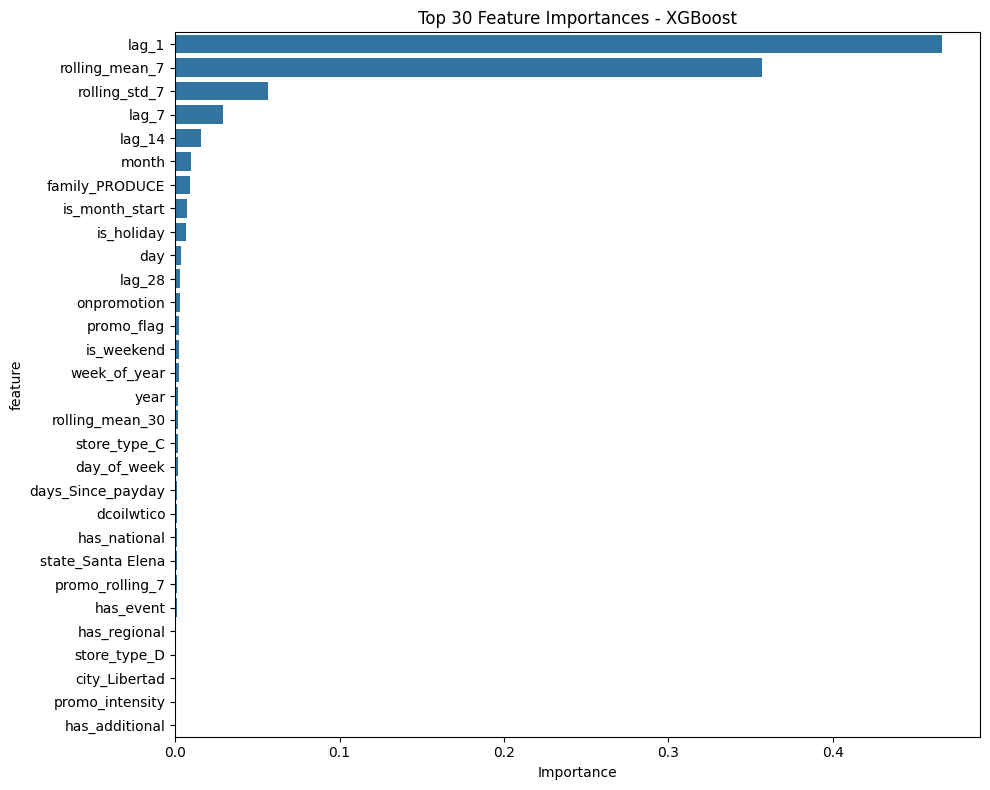

In [26]:
plt.figure(figsize=(10,8))
sns.barplot(data=fi_head, x="importance", y="feature")
plt.title("Top 30 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

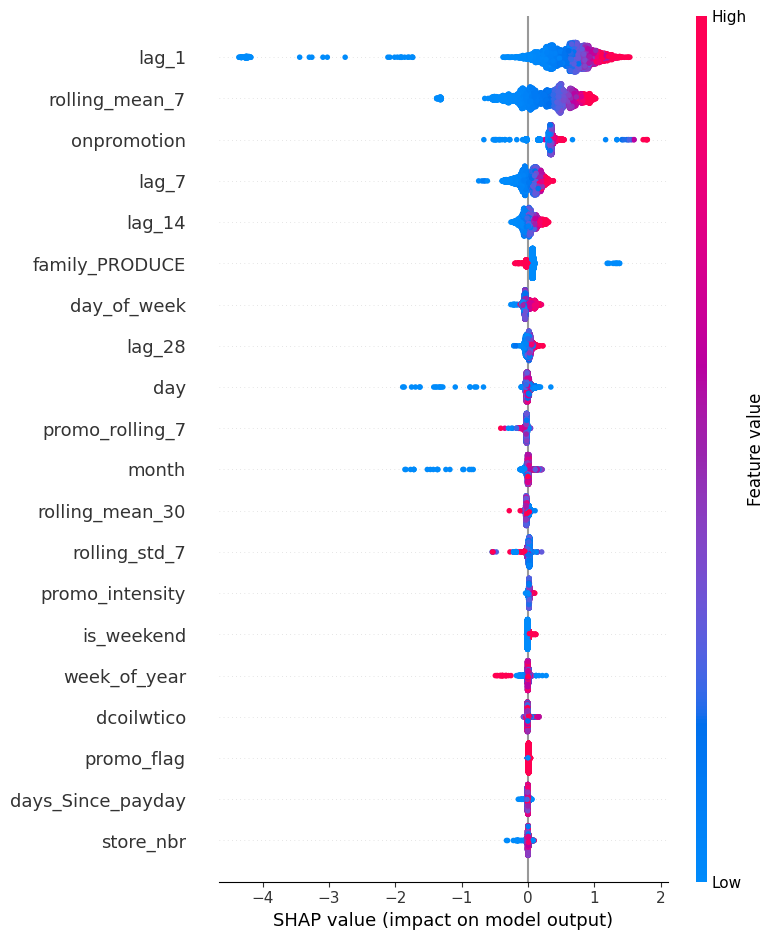

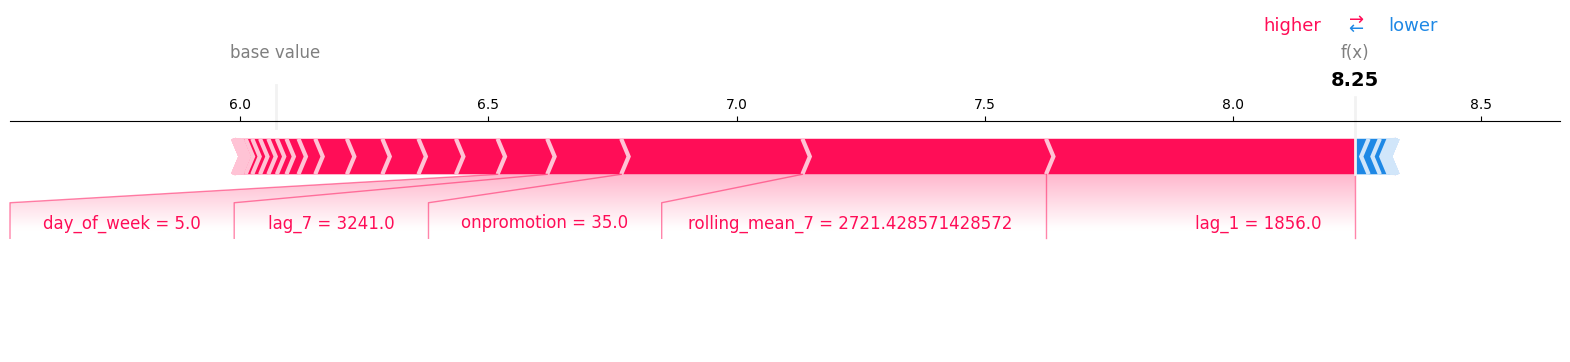

In [27]:
X_sample = x_test.sample(n=5000, random_state=42) 
X_pre = preprocessor.transform(X_sample)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_pre)
shap.summary_plot(shap_values, X_pre, feature_names=all_features, max_display=20)
i = 0
shap.force_plot(explainer.expected_value, shap_values[i,:], X_pre[i,:], feature_names=all_features, matplotlib=True)


<font size="5">SKU-Level Performance Evaluation</font>

In [28]:
test_df = test_df.copy()
test_df["forecast"] = xgb_pred
test_df["abs_error"] = abs(test_df["sales"] - test_df["forecast"])
test_df["squared_error"] = (test_df["sales"] - test_df["forecast"])**2

In [29]:
sku_perf = (
    test_df.groupby(["store_nbr", "family"])
    .agg(
        mean_sales=("sales","mean"),
        MAE=("abs_error","mean"),
        RMSE=("squared_error", lambda x: np.sqrt(np.mean(x)))
    )
    .reset_index()
)
sku_perf.head()

,store_nbr,family,mean_sales,MAE,RMSE
0,1,BEVERAGES,2172.792952,301.574007,422.776686
1,1,CLEANING,662.352423,91.099640,128.701235
2,1,DAIRY,725.775330,82.313459,117.235317
3,1,GROCERY I,2614.387665,349.654502,517.507226
4,1,PRODUCE,2506.538398,309.279949,432.961385


In [30]:
sku_perf["demand_level"] = pd.qcut(
    sku_perf["mean_sales"],
    q=2,
    labels=["Low Demand", "High Demand"]
)
sku_perf.groupby("demand_level")[["MAE", "RMSE"]].mean()

C:\Users\Vaishnavi Kulkarni\AppData\Local\Temp\ipykernel_28648\1554724995.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sku_perf.groupby("demand_level")[["MAE", "RMSE"]].mean()


,MAE,RMSE
demand_level,,
Low Demand,139.766382,235.621518
High Demand,512.533989,811.994465


In [31]:
sku_perf["relative_rmse"] = sku_perf["RMSE"] / sku_perf["mean_sales"]
sku_perf.groupby("demand_level")[["MAE","RMSE","relative_rmse"]].mean()

C:\Users\Vaishnavi Kulkarni\AppData\Local\Temp\ipykernel_28648\1132665298.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sku_perf.groupby("demand_level")[["MAE","RMSE","relative_rmse"]].mean()


,MAE,RMSE,relative_rmse
demand_level,,,
Low Demand,139.766382,235.621518,0.245393
High Demand,512.533989,811.994465,0.203083


<font size="5">Model Stability Check</font>

In [32]:
sku_perf["RMSE"].describe()

count     270.000000
mean      523.807991
std       476.625479
min        34.986139
25%       186.089519
50%       380.347253
75%       678.931041
max      2542.392602
Name: RMSE, dtype: float64

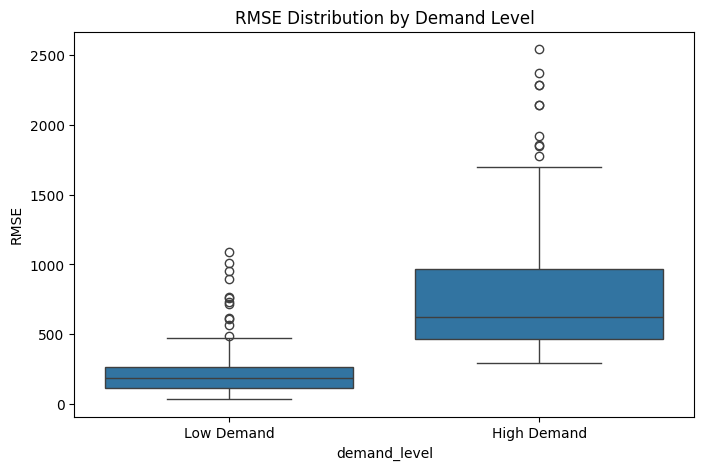

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=sku_perf, x="demand_level", y="RMSE")
plt.title("RMSE Distribution by Demand Level")
plt.show()

In [34]:
import joblib
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']